# Part 1 ‐ Exploratory data analysis

Let's import the two files, visualize logins, and work towards a correlation heatmap.

# Project Setup

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
from dateutil.relativedelta import relativedelta
import seaborn as sns

In [2]:
import statsmodels.api as sm
from statsmodels.graphics.api import abline_plot
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn import linear_model, preprocessing
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.metrics import root_mean_squared_error, r2_score
 
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.filterwarnings(action="ignore", module="scipy", message="^internal gelsd")

In [3]:
df_e = pd.read_csv('takehome_user_engagement.csv')

In [4]:
df_u = pd.read_excel('takehome_users.ods', engine="odf")

# Exploratory Data Analysis

As a start, let's take a look at the data.

In [5]:
df_e.head()

,time_stamp,user_id,visited
0,2014-04-22 03:53:30,1,1
1,2013-11-15 03:45:04,2,1
2,2013-11-29 03:45:04,2,1
3,2013-12-09 03:45:04,2,1
4,2013-12-25 03:45:04,2,1


In [6]:
df_e.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207917 entries, 0 to 207916
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   time_stamp  207917 non-null  object
 1   user_id     207917 non-null  int64 
 2   visited     207917 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 4.8+ MB


In [7]:
df_e.describe()

,user_id,visited
count,207917.000000,207917.0
mean,5913.314197,1.0
std,3394.941674,0.0
min,1.000000,1.0
25%,3087.000000,1.0
50%,5682.000000,1.0
75%,8944.000000,1.0
max,12000.000000,1.0


In [8]:
df_u.head()

,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1.398139e+09,1,0,11,10803.0
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,1.396238e+09,0,0,1,316.0
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,1.363735e+09,0,0,94,1525.0
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,1.369210e+09,0,0,1,5151.0
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,1.358850e+09,0,0,193,5240.0


In [9]:
df_u.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   object_id                   12000 non-null  int64  
 1   creation_time               12000 non-null  object 
 2   name                        12000 non-null  object 
 3   email                       12000 non-null  object 
 4   creation_source             12000 non-null  object 
 5   last_session_creation_time  8823 non-null   float64
 6   opted_in_to_mailing_list    12000 non-null  int64  
 7   enabled_for_marketing_drip  12000 non-null  int64  
 8   org_id                      12000 non-null  int64  
 9   invited_by_user_id          6417 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 937.6+ KB


In [10]:
df_u.shape

(12000, 10)

In [11]:
df_u.iloc[-1]

object_id                                         12000
creation_time                       2014-01-26 08:57:12
name                                         Lima Thaís
email                         ThaisMeloLima@hotmail.com
creation_source                                  SIGNUP
last_session_creation_time                 1390726632.0
opted_in_to_mailing_list                              0
enabled_for_marketing_drip                            1
org_id                                                0
invited_by_user_id                                  NaN
Name: 11999, dtype: object

In [12]:
df_u['object_id'].nunique()

12000

In [13]:
print(df_u['object_id'].max())

12000


In [14]:
print(df_u['object_id'].min())

1


The `object_id` column, which the dictionary describes as the `user_id` data, can simply be the dataframe index.

In [15]:
df_u = df_u.set_index('object_id')

In [16]:
df_u.describe()

,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id
count,8.823000e+03,12000.000000,12000.000000,12000.000000,6417.000000
mean,1.379279e+09,0.249500,0.149333,141.884583,5962.957145
std,1.953116e+07,0.432742,0.356432,124.056723,3383.761968
min,1.338452e+09,0.000000,0.000000,0.000000,3.000000
25%,1.363195e+09,0.000000,0.000000,29.000000,3058.000000
50%,1.382888e+09,0.000000,0.000000,108.000000,5954.000000
75%,1.398443e+09,0.000000,0.000000,238.250000,8817.000000
max,1.402067e+09,1.000000,1.000000,416.000000,11999.000000


We note that in `df_u` there are strings as datetimes. We should convert these columns.

In [17]:
df_u['last_sess_dt'] = pd.to_datetime(df_u['last_session_creation_time'], unit='s')

In [18]:
df_u['creation_dt'] = pd.to_datetime(df_u['creation_time'])

In [19]:
df_u.head()

,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,last_sess_dt,creation_dt
object_id,,,,,,,,,,,
1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1.398139e+09,1,0,11,10803.0,2014-04-22 03:53:30,2014-04-22 03:53:30
2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,1.396238e+09,0,0,1,316.0,2014-03-31 03:45:04,2013-11-15 03:45:04
3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,1.363735e+09,0,0,94,1525.0,2013-03-19 23:14:52,2013-03-19 23:14:52
4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,1.369210e+09,0,0,1,5151.0,2013-05-22 08:09:28,2013-05-21 08:09:28
5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,1.358850e+09,0,0,193,5240.0,2013-01-22 10:14:20,2013-01-17 10:14:20


We don't need to keep the entire email address, but the email service provider may have clues for marketing and persona type. Let's extract it into a new column and discard the rest.

In [20]:
df_u['email_stem'] = df_u['email'].str.split('@').str[1]

In [21]:
df_u.head()

,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,last_sess_dt,creation_dt,email_stem
object_id,,,,,,,,,,,,
1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1.398139e+09,1,0,11,10803.0,2014-04-22 03:53:30,2014-04-22 03:53:30,yahoo.com
2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,1.396238e+09,0,0,1,316.0,2014-03-31 03:45:04,2013-11-15 03:45:04,gustr.com
3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,1.363735e+09,0,0,94,1525.0,2013-03-19 23:14:52,2013-03-19 23:14:52,gustr.com
4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,1.369210e+09,0,0,1,5151.0,2013-05-22 08:09:28,2013-05-21 08:09:28,yahoo.com
5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,1.358850e+09,0,0,193,5240.0,2013-01-22 10:14:20,2013-01-17 10:14:20,yahoo.com


In [22]:
df_u['creation_dt'].max()

Timestamp('2014-05-30 23:59:19')

In [23]:
df_u['creation_dt'].min()

Timestamp('2012-05-31 00:43:27')

In [24]:
df_u = df_u.drop(columns=['email', 'creation_time', 'last_session_creation_time'])

## Observing Date and Time Patterns

There may be some value in the month and day of the week that users create their account or even last session.

We note that there were only `8823` non-null values in this column. This suggests that `12000 - 8823 = 3177` people signed up for an account, but never actually logged in. By default, these are already non-adopted users. We'll leave this data in for now, but we'll need to convert this information into something else before we train a model. Perhaps we can create an overall "user showed any sign of activity" duration column.

### Creation-Date Visual Inspection

Let's start with simply looking at the year and month that users joined.

In [25]:
df_u['creation_year'] = df_u['creation_dt'].dt.year.astype(str)

In [26]:
df_u['creation_month'] = df_u['creation_dt'].dt.month.astype(str)

In [27]:
def month_as_dig(month):
    if pd.isna(month) == True:
        return month
    if len(month) == 1:
        return '0' + month
    else:
        return month

In [28]:
df_u['creation_month'] = df_u['creation_month'].apply(month_as_dig)

In [29]:
df_u['creation_yr_mth'] = df_u['creation_year'] + ' ' + df_u['creation_month']

In [30]:
count_creation_yr_mth = df_u['creation_yr_mth'].value_counts().sort_index()

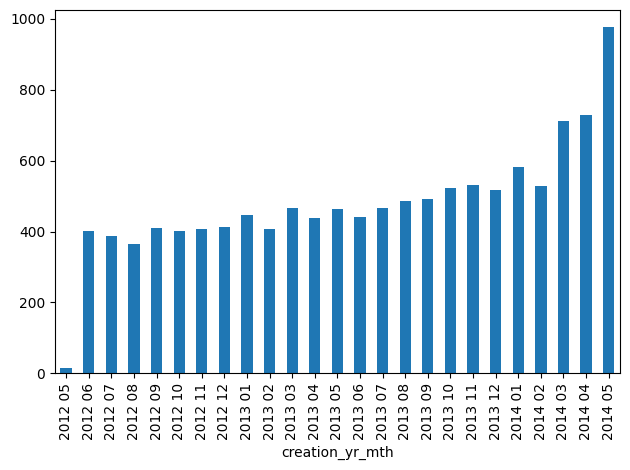

In [31]:
ax = count_creation_yr_mth.plot.bar()
n = 1
for index, label in enumerate(ax.get_xticklabels()):
    if index % n != 0:
        label.set_visible(False)

plt.tight_layout()
plt.show()

We can see that generally more users joined recently than in the past.

Now, let's look at time of the week people joined.

In [32]:
def day_as_dig(day):
   if day == 'Monday':
       return '00'
   elif day == 'Tuesday':
       return '01'
   elif day == 'Wednesday':
       return '02'
   elif day == 'Thursday':
       return '03'
   elif day == 'Friday':
       return '04'
   elif day == 'Saturday':
       return '05'
   elif day == 'Sunday':
       return '06'

In [33]:
df_u['creation_day'] = df_u['creation_dt'].dt.day_name()

In [34]:
df_u['creation_day_as_dig'] = df_u['creation_day'].apply(day_as_dig)

In [35]:
df_u['creation_60min_inc'] = df_u['creation_dt'].dt.floor('60min')

In [36]:
df_u['creation_60min_as_str'] = df_u['creation_60min_inc'].dt.time.apply(lambda x: x.strftime('%H:%M'))

In [37]:
df_u['creation_day_60min'] = df_u['creation_day_as_dig'] + ' ' + df_u['creation_60min_as_str']

In [38]:
creation_counts_60min = df_u['creation_day_60min'].value_counts().sort_index()

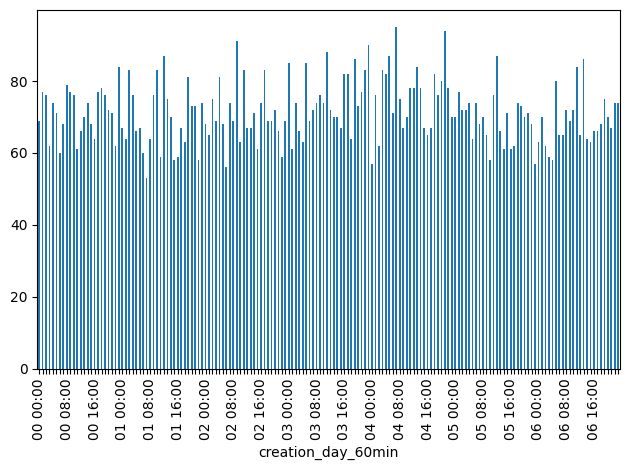

In [39]:
ax = creation_counts_60min.plot.bar()
n = 8
for index, label in enumerate(ax.get_xticklabels()):
    label.set_rotation(90)
    if index % n != 0:
        label.set_visible(False)

plt.tight_layout()
plt.show()

The time of the week appears to be inorganic. This looks like it could be generated data.

### Last-Session Visual Inspection

Now, let's perform the same simple EDA for the last-session times.

In [40]:
df_u['last_sess_year'] = df_u[df_u['last_sess_dt'].isnull() == False]['last_sess_dt'].dt.year.astype(str)#.str[:-2]

In [41]:
df_u['last_sess_month'] = df_u[df_u['last_sess_dt'].isnull() == False]['last_sess_dt'].dt.month.astype(str)#.str[:-2]

In [42]:
df_u['last_sess_month'] = df_u['last_sess_month'].apply(month_as_dig)

In [43]:
temp_df_u = df_u[(pd.isna(df_u['last_sess_year']) == False) & (pd.isna(df_u['last_sess_month']) == False)]

In [44]:
temp_df_u.loc[:,'last_sess_yr_mth'] = temp_df_u.loc[:,'last_sess_year'] + ' ' + temp_df_u.loc[:,'last_sess_month']

/tmp/ipykernel_943990/3086814379.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df_u.loc[:,'last_sess_yr_mth'] = temp_df_u.loc[:,'last_sess_year'] + ' ' + temp_df_u.loc[:,'last_sess_month']


In [45]:
count_last_sess_yr_mth = temp_df_u['last_sess_yr_mth'].value_counts().sort_index()

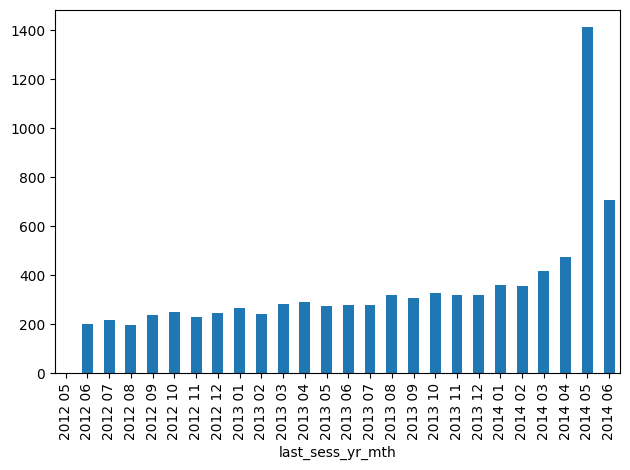

In [46]:
ax = count_last_sess_yr_mth.plot.bar()
n = 1
for index, label in enumerate(ax.get_xticklabels()):
    if index % n != 0:
        label.set_visible(False)

plt.tight_layout()
plt.show()

So, there is a gradual dropoff of sessions, which is to be expected. 

Since there is a boost around `2014-05`, we should create a boolean column that tracks whether the user has logged in since that time.

In [47]:
df_u['last_sess_is_recent'] = df_u['last_sess_dt'] > pd.to_datetime('2014-04-30')

In [48]:
df_u.head()

,name,creation_source,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,last_sess_dt,creation_dt,email_stem,creation_year,creation_month,creation_yr_mth,creation_day,creation_day_as_dig,creation_60min_inc,creation_60min_as_str,creation_day_60min,last_sess_year,last_sess_month,last_sess_is_recent
object_id,,,,,,,,,,,,,,,,,,,,
1,Clausen August,GUEST_INVITE,1,0,11,10803.0,2014-04-22 03:53:30,2014-04-22 03:53:30,yahoo.com,2014,04,2014 04,Tuesday,01,2014-04-22 03:00:00,03:00,01 03:00,2014,04,False
2,Poole Matthew,ORG_INVITE,0,0,1,316.0,2014-03-31 03:45:04,2013-11-15 03:45:04,gustr.com,2013,11,2013 11,Friday,04,2013-11-15 03:00:00,03:00,04 03:00,2014,03,False
3,Bottrill Mitchell,ORG_INVITE,0,0,94,1525.0,2013-03-19 23:14:52,2013-03-19 23:14:52,gustr.com,2013,03,2013 03,Tuesday,01,2013-03-19 23:00:00,23:00,01 23:00,2013,03,False
4,Clausen Nicklas,GUEST_INVITE,0,0,1,5151.0,2013-05-22 08:09:28,2013-05-21 08:09:28,yahoo.com,2013,05,2013 05,Tuesday,01,2013-05-21 08:00:00,08:00,01 08:00,2013,05,False
5,Raw Grace,GUEST_INVITE,0,0,193,5240.0,2013-01-22 10:14:20,2013-01-17 10:14:20,yahoo.com,2013,01,2013 01,Thursday,03,2013-01-17 10:00:00,10:00,03 10:00,2013,01,False


Let's look at the overall time of the week that users are initiating their last session.

In [49]:
df_u['last_sess_day'] = df_u[df_u['last_sess_dt'].isna() == False]['last_sess_dt'].dt.day_name()

In [50]:
df_u['last_sess_day_as_dig'] = df_u['last_sess_day'].apply(day_as_dig).astype(str)

In [51]:
df_u['last_sess_day_as_dig'].head()

object_id
1    01
2    00
3    01
4    02
5    01
Name: last_sess_day_as_dig, dtype: object

In [52]:
df_u['last_sess_day_as_dig'].info()

<class 'pandas.core.series.Series'>
Index: 12000 entries, 1 to 12000
Series name: last_sess_day_as_dig
Non-Null Count  Dtype 
--------------  ----- 
12000 non-null  object
dtypes: object(1)
memory usage: 187.5+ KB


In [53]:
df_u['last_sess_60min_inc'] = df_u['last_sess_dt'].dt.floor('60min')

In [54]:
df_u['last_sess_60min_as_str'] = df_u[df_u['last_sess_60min_inc'].isna() == False ]['last_sess_60min_inc'].dt.time.apply(lambda x: x.strftime('%H:%M'))

In [55]:
df_u['last_sess_60min_as_str'].info()

<class 'pandas.core.series.Series'>
Index: 12000 entries, 1 to 12000
Series name: last_sess_60min_as_str
Non-Null Count  Dtype 
--------------  ----- 
8823 non-null   object
dtypes: object(1)
memory usage: 187.5+ KB


In [56]:
df_u['last_sess_60min_as_str'].head()

object_id
1    03:00
2    03:00
3    23:00
4    08:00
5    10:00
Name: last_sess_60min_as_str, dtype: object

In [57]:
print(type(df_u['last_sess_60min_as_str'].iloc[0]))

<class 'str'>


In [58]:
temp_df_u = df_u[(df_u['last_sess_day_as_dig'].isna() == False) & (df_u['last_sess_60min_as_str'].isna() == False)]

In [59]:
temp_df_u.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8823 entries, 1 to 12000
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   name                        8823 non-null   object        
 1   creation_source             8823 non-null   object        
 2   opted_in_to_mailing_list    8823 non-null   int64         
 3   enabled_for_marketing_drip  8823 non-null   int64         
 4   org_id                      8823 non-null   int64         
 5   invited_by_user_id          4776 non-null   float64       
 6   last_sess_dt                8823 non-null   datetime64[ns]
 7   creation_dt                 8823 non-null   datetime64[ns]
 8   email_stem                  8823 non-null   object        
 9   creation_year               8823 non-null   object        
 10  creation_month              8823 non-null   object        
 11  creation_yr_mth             8823 non-null   object        
 

In [60]:
temp_df_u.loc[:, 'last_sess_day_60min'] = temp_df_u.loc[:, 'last_sess_day_as_dig'] + ' ' + temp_df_u.loc[:,'last_sess_60min_as_str']

/tmp/ipykernel_943990/1600433189.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df_u.loc[:, 'last_sess_day_60min'] = temp_df_u.loc[:, 'last_sess_day_as_dig'] + ' ' + temp_df_u.loc[:,'last_sess_60min_as_str']


In [61]:
last_sess_counts_60min = temp_df_u['last_sess_day_60min'].value_counts().sort_index()

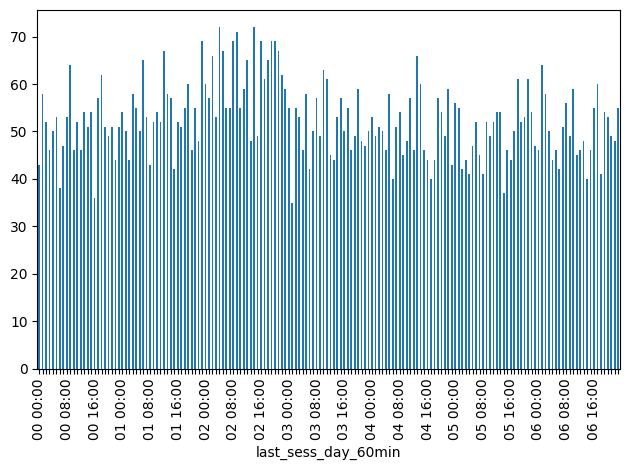

In [62]:
ax = last_sess_counts_60min.plot.bar()
n = 8
for index, label in enumerate(ax.get_xticklabels()):
    label.set_rotation(90)
    if index % n != 0:
        label.set_visible(False)

plt.tight_layout()
plt.show()

Once again, the timestamps are highly uniform, suggesting that the data may be inorganic.

### Calculating Duration

One primary value of the `last_session` column is to know the duration of time that a user was active on the app. 

We want to study the time period between account creation and last activity. We just care about duration, so number of days total will suffice.

The rest of the time stamp information will likely be dropped.

In [63]:
def get_duration(x, y):
    if (pd.isna(x) == True) or (pd.isna(y) == True):
        return np.nan
    else:
        return (x - y).days

In [64]:
df_u['activity_duration'] = df_u.apply(lambda row: get_duration(row['last_sess_dt'], row['creation_dt']), axis=1)

In [65]:
df_u['activity_duration'].head()

object_id
1      0.0
2    136.0
3      0.0
4      1.0
5      5.0
Name: activity_duration, dtype: float64

In [66]:
print(type(df_u['activity_duration'].iloc[0]))

<class 'numpy.float64'>


In [67]:
df_u['duration_score_bins'] = pd.cut(df_u['activity_duration'], bins=50)

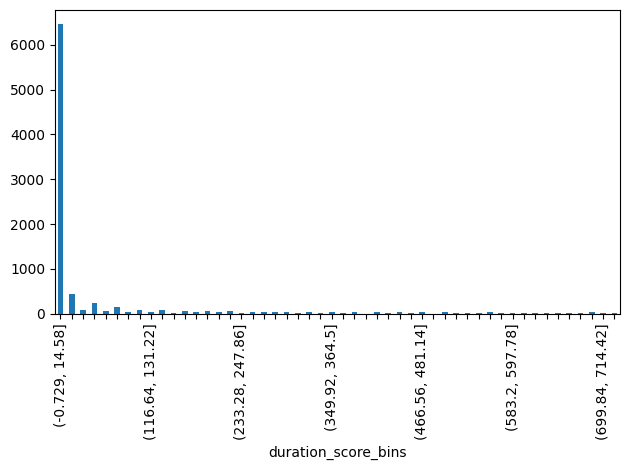

In [68]:
ax = df_u['duration_score_bins'].value_counts().sort_index().plot.bar()
n = 8
for index, label in enumerate(ax.get_xticklabels()):
    label.set_rotation(90)
    if index % n != 0:
        label.set_visible(False)

plt.tight_layout()
plt.show()

We can see here that most users do not stay more than `14` days. A few stay up to `116` days, but the number of active users becomes much more sparse in the upper ranges.

## Determining `Adopted User` Status

It's now time to determine which users are 'adopted users,' per the definition.

In [69]:
df_e.describe()

,user_id,visited
count,207917.000000,207917.0
mean,5913.314197,1.0
std,3394.941674,0.0
min,1.000000,1.0
25%,3087.000000,1.0
50%,5682.000000,1.0
75%,8944.000000,1.0
max,12000.000000,1.0


Each time they visit, the `visited` column is marked as `1.0`, which essentially stands for `True`. This column seems, therefore, to have no value, since, by the existece of the row itself, we can already assume that the user visited.

In [70]:
df_e = df_e.drop(columns=['visited'])

Let's convert and visualize the index timestamps.

In [71]:
df_e = df_e.reset_index(drop=True)

In [72]:
df_e.head()

,time_stamp,user_id
0,2014-04-22 03:53:30,1
1,2013-11-15 03:45:04,2
2,2013-11-29 03:45:04,2
3,2013-12-09 03:45:04,2
4,2013-12-25 03:45:04,2


In [73]:
print(type(df_e['time_stamp'].iloc[0]))

<class 'str'>


In [74]:
df_e['login_dt'] = pd.to_datetime(df_e['time_stamp'])

In [75]:
df_e.head()

,time_stamp,user_id,login_dt
0,2014-04-22 03:53:30,1,2014-04-22 03:53:30
1,2013-11-15 03:45:04,2,2013-11-15 03:45:04
2,2013-11-29 03:45:04,2,2013-11-29 03:45:04
3,2013-12-09 03:45:04,2,2013-12-09 03:45:04
4,2013-12-25 03:45:04,2,2013-12-25 03:45:04


In [76]:
df_e = df_e.drop(columns=['time_stamp'])

For each `user_id`, we need to check and see if they have three `login_dt` values that are within a `7` day period.

If they do, in the other dataframe, `df_u`, we need to set a column `adopted_user` to `1` (and all other non-adopted users should be set to `0`). 

In [77]:
count_users_login = df_e['user_id'].value_counts()

In [78]:
count_users_login.shape

(8823,)

In [79]:
count_users_login.sort_values(ascending=False)

user_id
3623     606
906      600
1811     593
7590     590
8068     585
        ... 
9102       1
9103       1
9104       1
9105       1
12000      1
Name: count, Length: 8823, dtype: int64

In [80]:
count_users_login = pd.DataFrame(count_users_login)

In [81]:
count_users_login.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8823 entries, 3623 to 12000
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   count   8823 non-null   int64
dtypes: int64(1)
memory usage: 137.9 KB


In [82]:
count_users_login = count_users_login[count_users_login['count'] >= 3]

In [83]:
count_users_login.shape

(2248, 1)

We have simplified the dataset down to `2248` users who have logged in at least `3` times.

Now, we need to see if, for each user, the span of any set of `3` logins is less than `7` days. If so, we add that user to a temporary `adopted_user` dataframe. We will later use this temporary dataframe to update the overall `df_u` dataframe. 

In [84]:
count_users_login = count_users_login.reset_index(drop=False)

In [85]:
count_users_login.nunique()

user_id    2248
count       400
dtype: int64

In [86]:
count_users_login.head()

,user_id,count
0,3623,606
1,906,600
2,1811,593
3,7590,590
4,8068,585


In [87]:
count_users_login['adopted_user'] = 0
df_u['adopted_user'] = 0

In [88]:
verbose = False
for index, row in count_users_login.iterrows():
    if verbose: print(f'Processing user_id: {row['user_id']}')
    temp_df = df_e[df_e['user_id'] == row['user_id']]
    temp_df = temp_df.sort_values(by=['login_dt'], ascending=True)
    i = 0
    max_val = len(temp_df) - 1
    if verbose: print(f'Max index: {max_val}')
    for i in range(0,max_val):
        last_set = False
        pos_dur = False
        if i + 2 == max_val:
            if verbose: print(f'Reached last value: {max_val}')
            last_set = True
        if verbose: print(f'Checking {i} to {i + 2}')
        dur = (temp_df['login_dt'].iloc[i + 2] - temp_df['login_dt'].iloc[i]).days
        if dur <= 7:
            if verbose: print(f'Found adopted user: dur {dur}: {temp_df['login_dt'].iloc[i+2]} - {temp_df['login_dt'].iloc[i]}')
            pos_dur = True
            count_users_login.loc[
                count_users_login['user_id'] == row['user_id'],
                'adopted_user'
            ] = 1
        if last_set or pos_dur:
            break

In [89]:
count_users_login.head()

,user_id,count,adopted_user
0,3623,606,1
1,906,600,1
2,1811,593,1
3,7590,590,1
4,8068,585,1


In [90]:
count_users_login['adopted_user'].sum()

np.int64(1656)

There are `1656` users that can be considered to have adopted the platform.

These users will serve as our target for training purposes.

In [91]:
verbose = False
adjusted_users = 0
for i in range(0,len(count_users_login)):
    if verbose: print(count_users_login.iloc[i]['adopted_user'])
    if count_users_login.iloc[i]['adopted_user'] == 1:
        user_id = count_users_login.iloc[i]['user_id']
        if verbose: print(f'adjusting user: {user_id}')
        df_u.loc[user_id, 'adopted_user'] = 1

In [92]:
df_u.head()

,name,creation_source,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,last_sess_dt,creation_dt,email_stem,creation_year,...,last_sess_year,last_sess_month,last_sess_is_recent,last_sess_day,last_sess_day_as_dig,last_sess_60min_inc,last_sess_60min_as_str,activity_duration,duration_score_bins,adopted_user
object_id,,,,,,,,,,,,,,,,,,,,,
1,Clausen August,GUEST_INVITE,1,0,11,10803.0,2014-04-22 03:53:30,2014-04-22 03:53:30,yahoo.com,2014,...,2014,04,False,Tuesday,01,2014-04-22 03:00:00,03:00,0.0,"(-0.729, 14.58]",0
2,Poole Matthew,ORG_INVITE,0,0,1,316.0,2014-03-31 03:45:04,2013-11-15 03:45:04,gustr.com,2013,...,2014,03,False,Monday,00,2014-03-31 03:00:00,03:00,136.0,"(131.22, 145.8]",1
3,Bottrill Mitchell,ORG_INVITE,0,0,94,1525.0,2013-03-19 23:14:52,2013-03-19 23:14:52,gustr.com,2013,...,2013,03,False,Tuesday,01,2013-03-19 23:00:00,23:00,0.0,"(-0.729, 14.58]",0
4,Clausen Nicklas,GUEST_INVITE,0,0,1,5151.0,2013-05-22 08:09:28,2013-05-21 08:09:28,yahoo.com,2013,...,2013,05,False,Wednesday,02,2013-05-22 08:00:00,08:00,1.0,"(-0.729, 14.58]",0
5,Raw Grace,GUEST_INVITE,0,0,193,5240.0,2013-01-22 10:14:20,2013-01-17 10:14:20,yahoo.com,2013,...,2013,01,False,Tuesday,01,2013-01-22 10:00:00,10:00,5.0,"(-0.729, 14.58]",0


In [93]:
df_u.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12000 entries, 1 to 12000
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   name                        12000 non-null  object        
 1   creation_source             12000 non-null  object        
 2   opted_in_to_mailing_list    12000 non-null  int64         
 3   enabled_for_marketing_drip  12000 non-null  int64         
 4   org_id                      12000 non-null  int64         
 5   invited_by_user_id          6417 non-null   float64       
 6   last_sess_dt                8823 non-null   datetime64[ns]
 7   creation_dt                 12000 non-null  datetime64[ns]
 8   email_stem                  12000 non-null  object        
 9   creation_year               12000 non-null  object        
 10  creation_month              12000 non-null  object        
 11  creation_yr_mth             12000 non-null  object        


In [94]:
df_u[df_u['adopted_user'] == 1].shape

(1656, 27)

The number of users from our earlier work matches the number that are updated in the `df_u` dataframe.

## Articulating All Columns

We are almost ready to begin creating a correlation heatmap that can tell us which values are most associated with the `adopted_user` metric.

Let's go through each column, decide if it needs to be broken down further, dropped, or kept as-is.

We'll save everything we decide to keep in a new dataframe.

The name and the index (user_id) are not useful at this stage. The next four columns, however, are useful.

In [95]:
df = df_u[[
    'creation_source',
    'opted_in_to_mailing_list',
    'enabled_for_marketing_drip',
    'org_id'
]]

The `invited_by_user` id is interesting. This reveals information about the social network that led to the creation of the platform.

What can we learn about people who invite, how many times, and by whom they might be invited?

In [96]:
df.shape

(12000, 4)

In [97]:
print(type(df_u['invited_by_user_id'].iloc[0]))

<class 'numpy.float64'>


In [98]:
df_u['invited_by_user_id'].info()

<class 'pandas.core.series.Series'>
Index: 12000 entries, 1 to 12000
Series name: invited_by_user_id
Non-Null Count  Dtype  
--------------  -----  
6417 non-null   float64
dtypes: float64(1)
memory usage: 445.5 KB


Let's create a temporary dataframe to track the number of times a user has invited anyone.

In [99]:
temp_df = pd.DataFrame(df_u[df_u['invited_by_user_id'].isna() == False]['invited_by_user_id'].astype(int).value_counts().sort_values())

In [100]:
temp_df.head()

,count
invited_by_user_id,
5450,1
1144,1
8011,1
5613,1
8469,1


Let's track a few things:

- How many times a user has successfully invited someone into the platform.
- If a user was invited to the platform, how many times that inviter has invited someone into the platform

In [101]:
df.loc[:,'invited_by_user_id'] = df_u.loc[:,'invited_by_user_id']

/tmp/ipykernel_943990/46393610.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:,'invited_by_user_id'] = df_u.loc[:,'invited_by_user_id']


In [102]:
df.loc[:,'invited_by_user_id'] = df['invited_by_user_id'].fillna(0)

In [112]:
df.loc[:,'invited_by_user_id'] = df['invited_by_user_id'].astype(int)

In [104]:
df.loc[:, ['times_sent_invite', 'times_inviter_sent_invite']] = 0

In [105]:
verbose = False
for user_id, row in temp_df.iterrows():
    if verbose: print(f'index: {user_id}')
    df.loc[user_id, 'times_sent_invite'] = row['count']
    df.loc[df['invited_by_user_id'] == user_id, 'times_inviter_sent_invite'] = row['count']

In [106]:
df.sort_values(by=['times_sent_invite'], ascending=False).head()

,creation_source,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,times_sent_invite,times_inviter_sent_invite
object_id,,,,,,,
10741,ORG_INVITE,0,0,100,10741.0,13,13
2527,PERSONAL_PROJECTS,0,0,57,0.0,12,0
11770,SIGNUP,0,0,5,0.0,11,0
1525,GUEST_INVITE,1,1,94,9224.0,11,2
2308,PERSONAL_PROJECTS,0,0,10,0.0,11,0


We note that the first entry, `10741`, has a user_id that is the same as `invited_by_user_id`. Is this a widespread issue, or just a one-off?

In [107]:
temp_df = df.reset_index()

In [114]:
temp_df[temp_df['object_id'] == temp_df['invited_by_user_id']]

,object_id,creation_source,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,times_sent_invite,times_inviter_sent_invite
22,23,ORG_INVITE,1,0,6,23.0,3,3
49,50,GUEST_INVITE,0,0,61,50.0,7,7
120,121,GUEST_INVITE,1,0,402,121.0,7,7
177,178,ORG_INVITE,0,0,415,178.0,4,4
192,193,ORG_INVITE,1,0,122,193.0,6,6
...,...,...,...,...,...,...,...,...
11767,11768,ORG_INVITE,0,0,38,11768.0,5,5
11773,11774,ORG_INVITE,0,0,3,11774.0,5,5
11794,11795,ORG_INVITE,0,0,153,11795.0,5,5
11803,11804,GUEST_INVITE,0,0,26,11804.0,3,3


There's a high number of these users.

The reason behind this information is not clear in the data dictionary. 

Let's create an additional column that tracks whether the invites are circular and otherwise leave it alone.

In [116]:
df.loc[:,'invite_circular'] = 0

In [117]:
df.loc[df.index == df['invited_by_user_id'], 'invite_circular'] = 1

That's finished. 

Moving on. We don't need the creation and last session times, but we do need the overall duration of activity, the email stem, and the adopted_user status.

In [119]:
df[df['invite_circular'] == 1].head()

,creation_source,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,times_sent_invite,times_inviter_sent_invite,invite_circular
object_id,,,,,,,,
23,ORG_INVITE,1,0,6,23.0,3,3,1
50,GUEST_INVITE,0,0,61,50.0,7,7,1
121,GUEST_INVITE,1,0,402,121.0,7,7,1
178,ORG_INVITE,0,0,415,178.0,4,4,1
193,ORG_INVITE,1,0,122,193.0,6,6,1


In [120]:
df = df.join(df_u[['activity_duration', 'email_stem', 'adopted_user']], how='inner')

In [121]:
df.head()

,creation_source,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,times_sent_invite,times_inviter_sent_invite,invite_circular,activity_duration,email_stem,adopted_user
object_id,,,,,,,,,,,
1,GUEST_INVITE,1,0,11,10803.0,0,1,0,0.0,yahoo.com,0
2,ORG_INVITE,0,0,1,316.0,0,3,0,136.0,gustr.com,1
3,ORG_INVITE,0,0,94,1525.0,1,11,0,0.0,gustr.com,0
4,GUEST_INVITE,0,0,1,5151.0,0,7,0,1.0,yahoo.com,0
5,GUEST_INVITE,0,0,193,5240.0,0,5,0,5.0,yahoo.com,0


In [122]:
df['invited_by_user_id'] = df['invited_by_user_id'].astype(int)

In [124]:
df['activity_duration'] = df['activity_duration'].fillna(0)

In [125]:
df['activity_duration'] = df['activity_duration'].astype(int)

In [126]:
df.head()

,creation_source,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,times_sent_invite,times_inviter_sent_invite,invite_circular,activity_duration,email_stem,adopted_user
object_id,,,,,,,,,,,
1,GUEST_INVITE,1,0,11,10803,0,1,0,0,yahoo.com,0
2,ORG_INVITE,0,0,1,316,0,3,0,136,gustr.com,1
3,ORG_INVITE,0,0,94,1525,1,11,0,0,gustr.com,0
4,GUEST_INVITE,0,0,1,5151,0,7,0,1,yahoo.com,0
5,GUEST_INVITE,0,0,193,5240,0,5,0,5,yahoo.com,0


# Correlation Heatmap

Let's make a version version of the dataframe that we can use for a visual heatmap.

In [128]:
dfc = df.drop(columns=['creation_source', 'email_stem'])

In [131]:
dfc = dfc.corr()

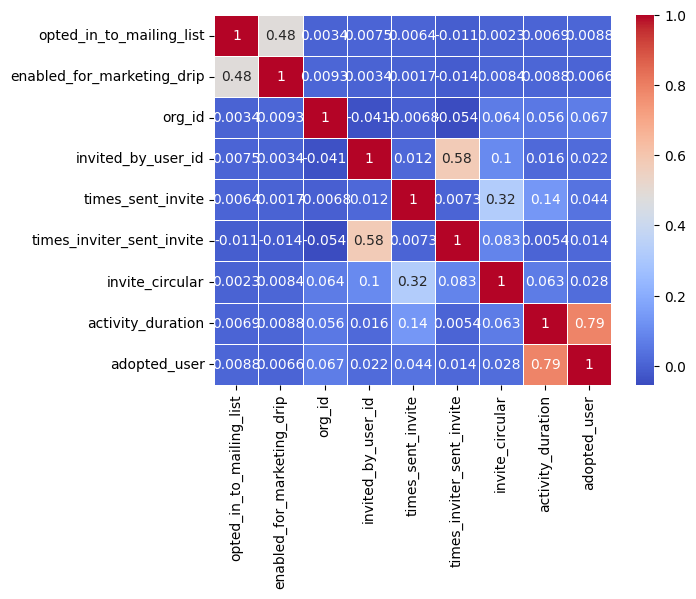

In [133]:
sns.heatmap(dfc, annot=True, cmap='coolwarm', linewidths=0.5)
plt.show()

It looks like `activity_duration` is the most correlated column.

This information is fairly obvious, however. The longer a user continues to show any sign of activity, the more likely they are to have a period of logging into the platform within a seven-day period.

## Mutual Info

Let's check whether the categorical columns are providing a high level of influence.

In [165]:
category_cols = ['creation_source', 'org_id', 'invited_by_user_id', 'email_stem']

In [167]:
from sklearn.metrics import mutual_info_score

for col in category_cols:
    score = mutual_info_score(df[col], df['adopted_user'])
    print(f"{col}: {score}")

creation_source: 0.004057195305157871
org_id: 0.022499037683939342
invited_by_user_id: 0.10511135773104138
email_stem: 0.041129966254788444


The `invited_by_user_id` categorical column is the most influential.

The fact that many users seemingly invited themselves makes this finding unclear.

Let's try it again, but without the circular invitees.

In [168]:
temp_df = df

In [173]:
temp_df.loc[temp_df['invite_circular'] == 1, 'invited_by_user_id'] = 0

In [174]:
from sklearn.metrics import mutual_info_score

for col in category_cols:
    score = mutual_info_score(temp_df[col], temp_df['adopted_user'])
    print(f"{col}: {score}")

creation_source: 0.004057195305157871
org_id: 0.022499037683939342
invited_by_user_id: 0.10224006980470987
email_stem: 0.041129966254788444


The effect only decreased that finding from `0.1051` to `0.1022`. 

This would suggest that the data in the column is robust enough to be useful for our continued analysis.

# Model Training

Let's build a model to predict how likely a user is to become an adopted user.

We will get dummy categories for every column that is categorical in nature.

In [166]:
dft = pd.get_dummies(df, columns=category_cols, prefix='c')

In [135]:
dft.columns = dft.columns.astype(str)

## Train Test Split

In [136]:
X = pd.DataFrame(dft.drop(columns=['adopted_user']))
y = pd.DataFrame(dft['adopted_user'])

In [137]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [138]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(9000, 4177)
(3000, 4177)
(9000, 1)
(3000, 1)


## Implementing a Scalar

In [139]:
scaler = StandardScaler()

In [140]:
scaler.fit(X_train)

,copy,True
,with_mean,True
,with_std,True


In [141]:
X_train_scaled = scaler.transform(X_train)

In [142]:
X_test_scaled = scaler.transform(X_test)

## Modeling

### Linear Regression

In [143]:
rModel = linear_model.LinearRegression()

In [144]:
y_train = y_train.rename(str,axis="columns")
y_test = y_test.rename(str,axis="columns")

In [145]:
rModel.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [146]:
y_pred = rModel.predict(X_train_scaled)

In [147]:
r2 = r2_score(y_train, y_pred)

In [148]:
print(r2)

0.7721666018570021


Our Linear Regression predictive model has an R2 score of `0.77`, which suggests that it can predict with approximately `77%` accuracy.

This may be overinflated, however, due to the `activity_duration` column.

Let's try again, but without that column.

## Second Round

In [149]:
temp_df = df.drop(columns=['activity_duration'])

In [150]:
dft = pd.get_dummies(temp_df, columns=['creation_source', 'org_id', 'invited_by_user_id', 'email_stem'], prefix='c')

In [151]:
dft.columns = dft.columns.astype(str)

## Train Test Split

In [152]:
X = pd.DataFrame(dft.drop(columns=['adopted_user']))
y = pd.DataFrame(dft['adopted_user'])

In [153]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [154]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(9000, 4176)
(3000, 4176)
(9000, 1)
(3000, 1)


## Implementing a Scalar

In [155]:
scaler = StandardScaler()

In [156]:
scaler.fit(X_train)

,copy,True
,with_mean,True
,with_std,True


In [157]:
X_train_scaled = scaler.transform(X_train)

In [158]:
X_test_scaled = scaler.transform(X_test)

## Modeling

### Linear Regression

In [159]:
rModel = linear_model.LinearRegression()

In [160]:
y_train = y_train.rename(str,axis="columns")
y_test = y_test.rename(str,axis="columns")

In [161]:
rModel.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [162]:
y_pred = rModel.predict(X_train_scaled)

In [163]:
r2 = r2_score(y_train, y_pred)

In [164]:
print(r2)

0.41151242576753533


Without that column, our model only provides an R2 score of `0.41`. This is a much lower R2 score, although it is large enough to provide some use.

# Overall Observations

The most import piece of information we found is that the person who does the inviting seems to be one of the most influential factors in deciding whether or not a new member becomes an adopted user.